In [48]:
from graph.higher_dim_graph import Graph
from graph.graph import restore_from_csv
import metrics.metrics as mtx
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import powerlaw

In [49]:
G_ru = restore_from_csv('UN_ru_graph.csv')
G_ru_nx = G_ru.convert_to_networkx()

G_en = restore_from_csv('UN_en_graph.csv')
G_en_nx = G_en.convert_to_networkx()

# Main metrix

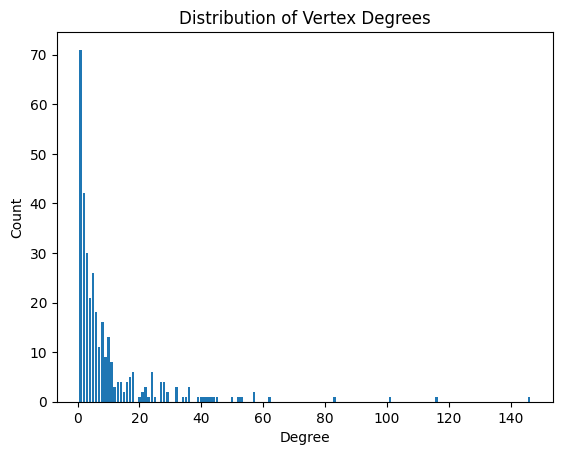

{10: 13,
 14: 4,
 18: 6,
 8: 16,
 57: 2,
 27: 4,
 53: 1,
 22: 3,
 32: 3,
 43: 1,
 11: 8,
 34: 1,
 12: 3,
 45: 1,
 29: 2,
 2: 42,
 1: 71,
 3: 30,
 5: 26,
 4: 21,
 24: 6,
 7: 11,
 83: 1,
 28: 4,
 146: 1,
 50: 1,
 42: 1,
 13: 4,
 44: 1,
 9: 9,
 6: 18,
 39: 1,
 52: 1,
 41: 1,
 101: 1,
 23: 1,
 62: 1,
 21: 2,
 17: 5,
 116: 1,
 36: 3,
 15: 2,
 35: 1,
 16: 4,
 25: 1,
 20: 1,
 40: 1}

In [50]:
mtx.distribution_of_degrees(G_ru)

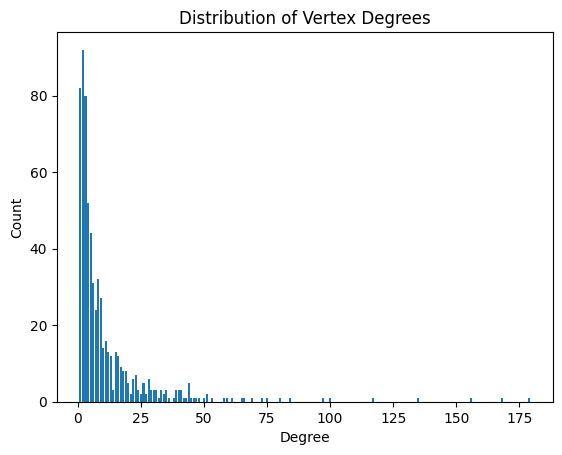

{1: 82,
 19: 8,
 51: 2,
 84: 1,
 18: 8,
 44: 5,
 117: 1,
 168: 1,
 26: 5,
 69: 1,
 13: 12,
 2: 92,
 20: 5,
 40: 3,
 6: 31,
 16: 12,
 23: 7,
 43: 1,
 8: 32,
 24: 3,
 100: 1,
 50: 1,
 17: 9,
 15: 13,
 12: 13,
 31: 3,
 27: 2,
 28: 6,
 25: 2,
 10: 14,
 75: 1,
 4: 52,
 179: 1,
 9: 27,
 5: 44,
 7: 24,
 58: 1,
 22: 6,
 11: 16,
 35: 3,
 42: 1,
 41: 3,
 39: 3,
 53: 1,
 3: 80,
 48: 1,
 135: 1,
 32: 1,
 66: 1,
 65: 1,
 30: 3,
 36: 1,
 34: 2,
 97: 1,
 73: 1,
 156: 1,
 29: 3,
 38: 1,
 33: 3,
 21: 2,
 47: 1,
 80: 1,
 61: 1,
 14: 3,
 59: 1,
 46: 1,
 45: 1}

In [51]:
mtx.distribution_of_degrees(G_en)

In [52]:
df = pd.DataFrame({'graph_en': mtx.calculate_metrics(G_en), 'graph_ru': mtx.calculate_metrics(G_ru)})
df.round(4)

,graph_en,graph_ru
num_vertices,671.0000,342.0000
num_edges,5898.0000,2541.0000
average_degree,17.5797,14.8596
density,0.0262,0.0436
average_clustering_coefficient,0.5312,0.3184
assortativity,-0.1552,-0.1906
connected_components,3.0000,4.0000
giant_component_size,667.0000,336.0000
average_shortest_path_length,2.9675,2.8762
diameter,7.0000,10.0000


- провести сквизинг
- проверить на других текстов 
- проверить совпадение вершин через переводы 
- посмотреть на совпадение хабов 

In [53]:
bc_ru = mtx.betweenness_centrality(G_ru)
bc_en = mtx.betweenness_centrality(G_en)
top_bc_ru = sorted(bc_ru.items(), key=lambda x: x[1], reverse=True)[:10]
top_bc_en = sorted(bc_en.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by betweenness centrality in Russian graph:")
for node, centrality in top_bc_ru:
    print(f"{node}: {centrality:.4f}")
print("\nTop 10 nodes by betweenness centrality in English graph:")
for node, centrality in top_bc_en:
    print(f"{node}: {centrality:.4f}")

Top 10 nodes by betweenness centrality in Russian graph:
статья: 0.2527
совет: 0.1485
член: 0.0982
организация: 0.0832
государство: 0.0541
ассамблея: 0.0443
территория: 0.0439
народ: 0.0418
условие: 0.0393
устав: 0.0380

Top 10 nodes by betweenness centrality in English graph:
article: 0.1726
council: 0.1233
security: 0.1129
member: 0.1126
respect: 0.0806
present charter: 0.0694
general assembly: 0.0532
international peace: 0.0507
unite nation: 0.0432
system: 0.0389


In [54]:
cc_ru = mtx.closeness_centrality(G_ru)
cc_en = mtx.closeness_centrality(G_en)
top_cc_ru = sorted(cc_ru.items(), key=lambda x: x[1], reverse=True)[:10]
top_cc_en = sorted(cc_en.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by closeness centrality in Russian graph:")
for node, centrality in top_cc_ru:
    print(f"{node}: {centrality:.4f}")
print("\nTop 10 nodes by closeness centrality in English graph:")
for node, centrality in top_cc_en:
    print(f"{node}: {centrality:.4f}")

Top 10 nodes by closeness centrality in Russian graph:
статья: 0.5794
совет: 0.5334
член: 0.5110
организация: 0.5079
государство: 0.4826
народ: 0.4742
ассамблея: 0.4695
устав: 0.4616
глава: 0.4609
действие: 0.4603

Top 10 nodes by closeness centrality in English graph:
article: 0.5296
security: 0.5221
council: 0.5205
member: 0.5061
international peace: 0.4882
general assembly: 0.4832
respect: 0.4797
present charter: 0.4756
unite nation: 0.4739
maintenance: 0.4626


In [55]:
evc_ru = mtx.eigenvector_centrality(G_ru)
evc_en = mtx.eigenvector_centrality(G_en)
top_evc_ru = sorted(evc_ru.items(), key=lambda x: x[1], reverse=True)[:10]
top_evc_en = sorted(evc_en.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by eigenvector centrality in Russian graph:")
for node, centrality in top_evc_ru:
    print(f"{node}: {centrality:.4f}")
print("\nTop 10 nodes by eigenvector centrality in English graph:")
for node, centrality in top_evc_en:
    print(f"{node}: {centrality:.4f}")

Top 10 nodes by eigenvector centrality in Russian graph:
статья: 0.3080
совет: 0.2533
член: 0.2459
организация: 0.2202
народ: 0.1710
государство: 0.1666
действие: 0.1662
глава: 0.1531
ассамблея: 0.1483
устав: 0.1477

Top 10 nodes by eigenvector centrality in English graph:
security: 0.2708
article: 0.2462
council: 0.2164
international peace: 0.2050
member: 0.1884
respect: 0.1591
principle: 0.1567
general assembly: 0.1514
unite nation: 0.1389
present charter: 0.1318


In [56]:
dc_ru = mtx.degree_centrality(G_ru)
dc_en = mtx.degree_centrality(G_en)
top_dc_ru = sorted(dc_ru.items(), key=lambda x: x[1], reverse=True)[:10]
top_dc_en = sorted(dc_en.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 nodes by degree centrality in Russian graph:")
for node, centrality in top_dc_ru:
    print(f"{node}: {centrality:.4f}")
print("\nTop 10 nodes by degree centrality in English graph:")
for node, centrality in top_dc_en:
    print(f"{node}: {centrality:.4f}")

Top 10 nodes by degree centrality in Russian graph:
статья: 0.4282
совет: 0.3402
член: 0.2962
организация: 0.2434
государство: 0.1818
народ: 0.1672
ассамблея: 0.1672
устав: 0.1554
действие: 0.1525
глава: 0.1466

Top 10 nodes by degree centrality in English graph:
article: 0.2672
security: 0.2507
council: 0.2328
member: 0.2015
international peace: 0.1746
respect: 0.1493
general assembly: 0.1448
unite nation: 0.1254
system: 0.1194
present charter: 0.1119


In [57]:
cl_coefs_ru = mtx.distribution_of_clustering_coefficients(G_ru)
cl_coefs_en = mtx.distribution_of_clustering_coefficients(G_en)
top_cl_ru = sorted(cl_coefs_ru.items(), key=lambda x: x[1], reverse=True)
top_cl_en = sorted(cl_coefs_en.items(), key=lambda x: x[1], reverse=True)
print("Top nodes by clustering coefficient in Russian graph:")
for node, coeff in top_cl_ru:
    if 1 > coeff > 0.8:
        print(f"{node}: {coeff:.4f}")
print("\nTop nodes by clustering coefficient in English graph:")
for node, coeff in top_cl_en:
    if 1 > coeff > 0.8:
        print(f"{node}: {coeff:.4f}")

Top nodes by clustering coefficient in Russian graph:
инициатива: 0.9000
доклад: 0.8667
увеличение: 0.8667
посещение: 0.8667
преимущество: 0.8333
вмешательство: 0.8333
существо: 0.8333
суждение: 0.8333
термин: 0.8333
компетенция: 0.8333
вид: 0.8333
приём: 0.8333
укрепление: 0.8214
предел: 0.8095
ущерб: 0.8095

Top nodes by clustering coefficient in English graph:
centre: 0.9778
common end: 0.9778
selfdetermination: 0.9722
specialized international body: 0.9722
social economic purpose: 0.9722
technical nature: 0.9722
such limitation: 0.9697
constitutional consideration: 0.9697
practical achievement: 0.9556
aggression: 0.9524
other breach: 0.9524
international dispute: 0.9429
economic advancement: 0.9417
further function: 0.9333
particular circumstance: 0.9333
vary stage: 0.9333
advancement: 0.9333
political aspiration: 0.9333
responsible state: 0.9333
their administration: 0.9333
mandatory power: 0.9286
information: 0.9273
common interest: 0.9231
free political institution: 0.9103
furth

# Jaccard similarity

In [58]:
def calculate_jaccard(list_a, list_b):
    """Вычисляет коэффициент Жаккара для двух списков."""
    set_a = set(list_a)
    set_b = set(list_b)
    
    intersection = set_a.intersection(set_b)
    union = set_a.union(set_b)
    
    if not union:
        return 0.0
        
    jaccard_index = len(intersection) / len(union)
    return jaccard_index, intersection

def translate_vertices(vertices, translation_dict):
    """Переводит вершины по словарю."""
    translated_vertices = []
    for vertex in vertices:
        words = vertex.lower().split()
        try:
            translated = ' '.join(translation_dict[word] for word in words)
            translated_vertices.append(translated)
        except KeyError:
            # print(vertex)
            pass
        
    return translated_vertices

In [59]:
with open('ru_en_dict.csv', 'r', encoding='utf-8') as f:
    ru_en_dict = {}
    en_ru_dict = {}
    for line in f:
        ru_word, en_word = line.strip().split(';')
        ru_en_dict[ru_word.lower()] = en_word.lower()
        en_ru_dict[en_word.lower()] = ru_word.lower()

In [60]:
en_vertices = [v.lower() for v in G_en.vertices.keys()]
ru_vertices = [v.lower() for v in G_ru.vertices.keys()]

translated_ru_vertices = translate_vertices(ru_vertices, ru_en_dict)
translated_en_vertices = translate_vertices(en_vertices, en_ru_dict)

jaccard_score, matched_nodes = calculate_jaccard(translated_ru_vertices, en_vertices)
print(f"Переведенные русские вершины: {translated_ru_vertices}")
print(f"Английские вершины: {en_vertices}")
print(f"Совпадающие узлы (пересечение): {matched_nodes}")
print(f"Коэффициент Жаккарда: {jaccard_score:.4f}")
print()

jaccard_score, matched_nodes = calculate_jaccard(translated_en_vertices, ru_vertices)
print(f"Переведенные английские вершины: {translated_en_vertices}")
print(f"Русские вершины: {ru_vertices}")
print(f"Совпадающие узлы (пересечение): {matched_nodes}")
print(f"Коэффициент Жаккарда: {jaccard_score:.4f}")

Переведенные русские вершины: ['equality', 'justice', 'un', 'neighbour', 'people', 'preamble', 'text', 'tolerance', 'charter', 'friend', 'virtue', 'we', 'condition', 'which', 'respect', 'obligation', 'treaty', 'purpose', 'progress', 'war', 'scourge', 'woman', 'man', 'life', 'establishment', 'method', 'whole', 'this', 'pursuit', 'our', 'worth', 'dignity', 'peace', 'representative', 'city', 'authorization', 'form', 'adjustment', 'organization', 'solution', 'article', 'chapter', 'principle', 'violation', 'measure', 'strengthening', 'threat', 'aggression', 'act', 'right', 'dispute', 'situation', 'race', 'difference', 'sex', 'language', 'development', 'action', 'harmonizing', 'nation', 'basis', 'human', 'conformity', 'member', 'exhaust', 'benefit', 'state', 'assistance', 'intervene', 'case', 'entity', 'order', 'grounds', 'equal', 'generation', 'rendering', 'nature', 'composition', 'declaration', 'participation', 'conference', 'creation', 'january', 'year', 'opinion', 'admission', 'consent',

# Power law

## Empirical CDF

In [61]:
def empirical_cdf(G):
    hist = np.array(nx.degree_histogram(G))
    p = hist / hist.sum()
    return np.cumsum(p)

In [62]:
GG_ru = G_ru_nx.subgraph(max(nx.connected_components(G_ru_nx), key=len))
GG_en = G_en_nx.subgraph(max(nx.connected_components(G_en_nx), key=len))

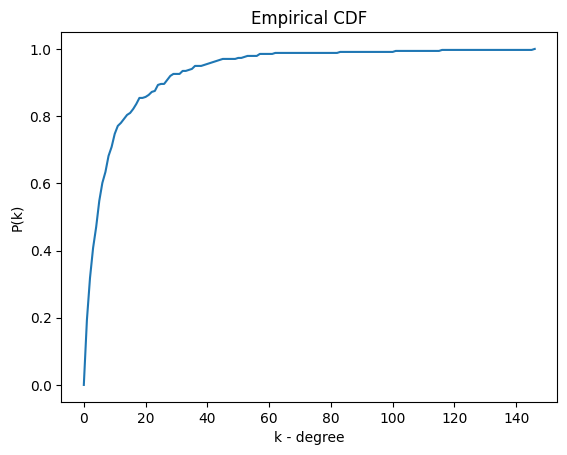

In [63]:
ecdf = empirical_cdf(GG_ru)
# assert np.all(ecdf[[0, -1]] == [0, 1])
# assert np.all(ecdf[:-1] <= ecdf[1:])

plt.plot(ecdf)
plt.xlabel('k - degree')
plt.ylabel('P(k)')
plt.title('Empirical CDF')
plt.show()

## Theoretical PDF

In [64]:
def pdf(x, alpha=2.5, x_min=1):
    C = (alpha - 1) / (x_min ** (-alpha + 1))
    return C * x ** (-alpha)

Text(0.5, 1.0, 'Theoretical PDF (Power law)')

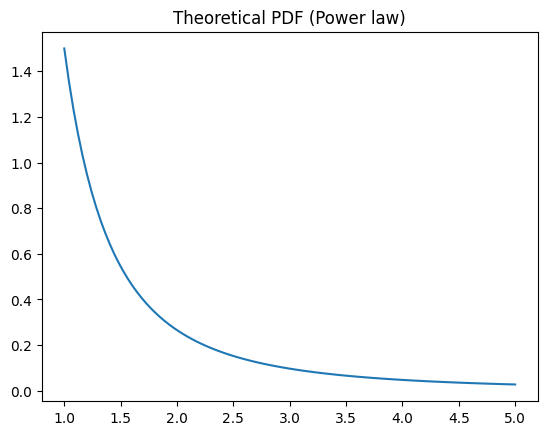

In [65]:
x_space = np.linspace(1, 5, 100)
plt.plot(x_space, pdf(x_space))
plt.title('Theoretical PDF (Power law)')

## Theoretical CDF

In [66]:
def cdf(x, alpha=2.5, x_min=1):
    return 1 - x ** (-alpha + 1) / x_min ** (-alpha + 1)

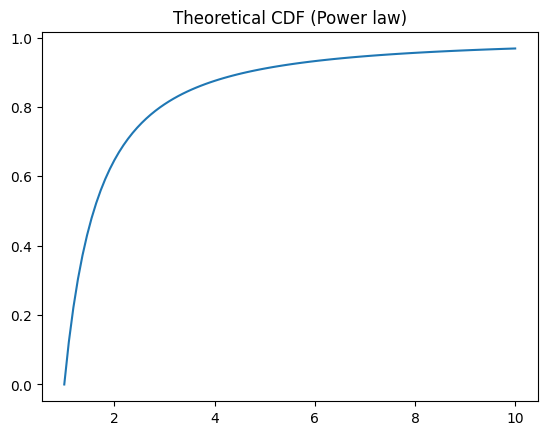

In [67]:
x_space = np.linspace(1, 10, 100)
plt.plot(x_space, cdf(x_space))
plt.title('Theoretical CDF (Power law)');

## PPF

In [68]:
def ppf(r, alpha=2.5, x_min=1):
    return (1 - r) ** (1/(-alpha + 1)) * x_min

Text(0.5, 1.0, 'PPF (Power law)')

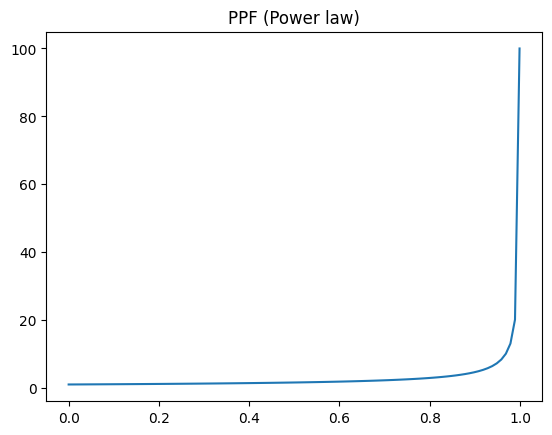

In [69]:
x_space = np.linspace(0, 0.999, 100)
plt.plot(x_space, ppf(x_space))
plt.title('PPF (Power law)')

In [70]:
def power_law(n, alpha=2.5, x_min=1, random_seed=0):
    np.random.seed(random_seed)
    r = np.random.uniform(0, 0.999, n)
    return ppf(r, alpha, x_min)

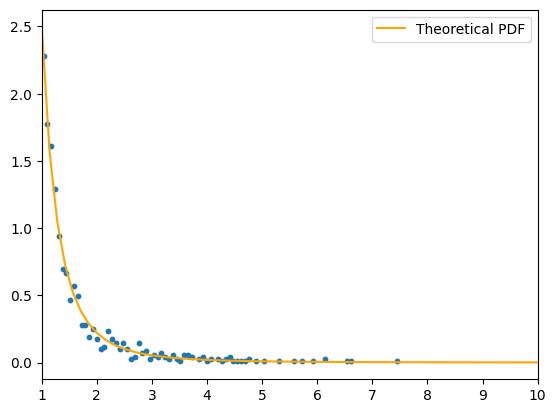

In [71]:
alpha = 3.5
x_min = 1
x_train = power_law(1000, alpha, x_min)
x_space = np.linspace(1, 15, 100)

#prepare histogram
hist, bin_edges = np.histogram(x_train, bins=200, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers[hist > 0], hist[hist > 0], s=10)

plt.plot(x_space, pdf(x_space, alpha, x_min),
         label='Theoretical PDF', c='orange')
plt.legend()
plt.xlim(1, 10)
plt.show()

## alpha estimation

In [72]:
from sklearn.linear_model import LinearRegression

def alpha_est(x_train, bins):
    # your code here
    hist, bin_edges = np.histogram(x_train, bins=bins, density=True)
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2

    idx = np.argwhere(hist > 0)
    log_centers = np.log(bin_centers[idx])
    log_hist = np.log(hist[idx])

    lr = LinearRegression().fit(log_centers.reshape(-1, 1), log_hist)
    return -lr.coef_[0][0]

In [73]:
bins = 100
x_train = power_law(1000, x_min=1, alpha=2, random_seed=1)
assert np.abs(alpha_est(x_train, bins) - 2) < 0.7
x_train = power_law(1000, x_min=1, alpha=2.5, random_seed=1)
assert np.abs(alpha_est(x_train, bins) - 2.5) < 0.9
x_train = power_law(1000, x_min=1, alpha=9, random_seed=1)
assert np.abs(alpha_est(x_train, bins) - 9) < 2

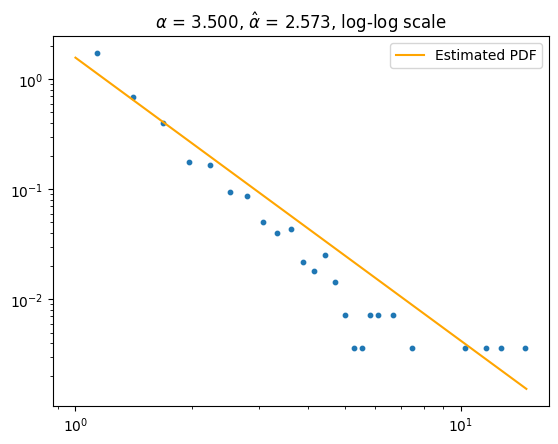

In [74]:
x_min = 1
alpha = 3.5
bins = 50

x_train = power_law(1000, alpha, x_min)
hist, bin_edges = np.histogram(x_train, bins=bins, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers, hist, s=10)

hat_alpha = alpha_est(x_train, bins)
x_space = np.linspace(x_min, x_train.max(), 100)
plt.plot(x_space, pdf(x_space, hat_alpha, x_min),
         label='Estimated PDF', c='orange')
plt.legend()
plt.title(r'$\alpha$ = {:.3f}, $\hat \alpha$ = {:.3f}, log-log scale'.format(alpha, hat_alpha))
plt.xscale('log')
plt.yscale('log')
plt.show()

In [75]:
from scipy.stats import kstest

def MLE_extimation(degree_sequence):
    # your code here
    x_min_list = []
    alpha_list = []
    test_list = []

    x_min_ = int(min(degree_sequence))
    x_max_ = int(max(degree_sequence))

    for x_min in range(x_min_, x_max_):
      degree_sequence_new = degree_sequence[degree_sequence >= x_min]

      alpha = 1 + len(degree_sequence_new) * (np.sum(np.log(degree_sequence_new/x_min))) ** (-1)

      test = kstest(degree_sequence_new, cdf=cdf, args=(alpha, x_min))

      if np.isnan(test.statistic): continue

      x_min_list.append(x_min)
      alpha_list.append(alpha)
      test_list.append(test.statistic)
    idx = np.argmin(test_list)
    return alpha_list[idx], x_min_list[idx]

In [76]:
degree_sequence_ru = np.array(sorted([GG_ru.degree[node] for node in GG_ru.nodes]))
degree_sequence_en = np.array(sorted([GG_en.degree[node] for node in GG_en.nodes]))

hat_alpha_ru, hat_x_min_ru = MLE_extimation(degree_sequence_ru)
hat_alpha_en, hat_x_min_en = MLE_extimation(degree_sequence_en)

/var/folders/v3/g9p917f512s52x0xb8r6htn00000gn/T/ipykernel_7953/559381187.py:2: RuntimeWarning: invalid value encountered in divide
  return 1 - x ** (-alpha + 1) / x_min ** (-alpha + 1)


Text(0.5, 1.0, 'RU graph')

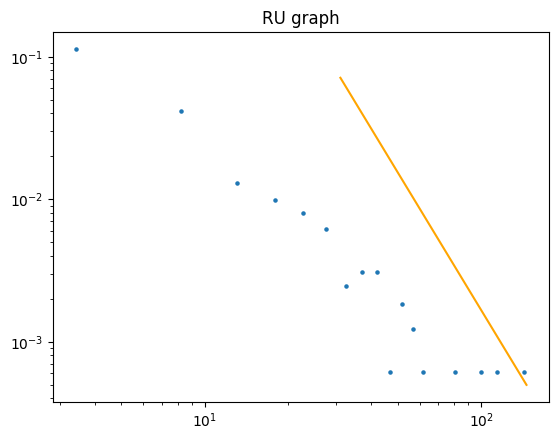

In [77]:
hist, bin_edges = np.histogram(degree_sequence_ru, bins=30, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers[hist > 0], hist[hist > 0], s=5)

hat_alpha, hat_x_min = MLE_extimation(degree_sequence_ru)
x_space = np.linspace(hat_x_min, degree_sequence_ru.max(), 100)
plt.plot(x_space, pdf(x_space, hat_alpha, hat_x_min),
         label='Estimated PDF', c='orange')
plt.xscale('log')
plt.yscale('log')
plt.title('RU graph')

/var/folders/v3/g9p917f512s52x0xb8r6htn00000gn/T/ipykernel_7953/559381187.py:2: RuntimeWarning: invalid value encountered in divide
  return 1 - x ** (-alpha + 1) / x_min ** (-alpha + 1)


Text(0.5, 1.0, 'EN graph')

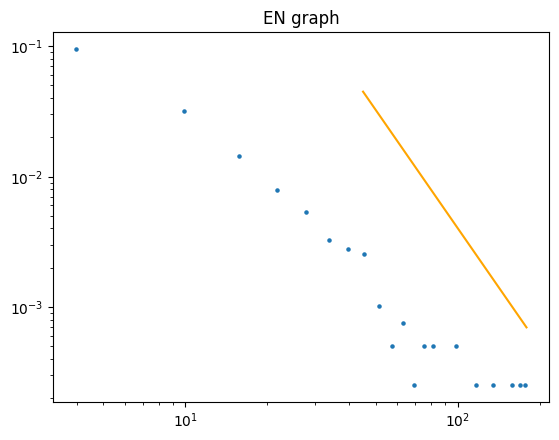

In [78]:
hist, bin_edges = np.histogram(degree_sequence_en, bins=30, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers[hist > 0], hist[hist > 0], s=5)

hat_alpha, hat_x_min = MLE_extimation(degree_sequence_en)
x_space = np.linspace(hat_x_min, degree_sequence_en.max(), 100)
plt.plot(x_space, pdf(x_space, hat_alpha, hat_x_min),
         label='Estimated PDF', c='orange')
plt.xscale('log')
plt.yscale('log')
plt.title('EN graph')

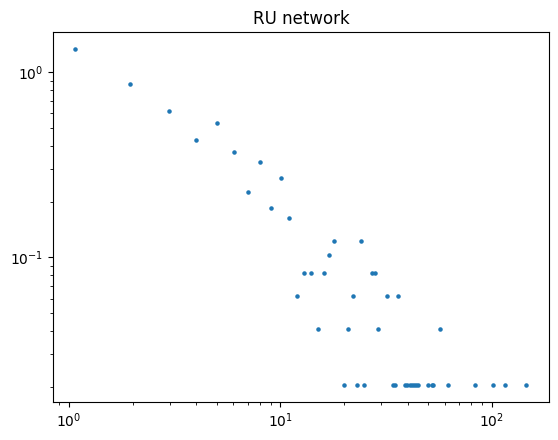

In [79]:
hist, bin_edges = np.histogram(degree_sequence_ru, bins=1000, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers[hist > 0], hist[hist > 0], s=5)
plt.title('RU network')
plt.xscale('log')
plt.yscale('log')

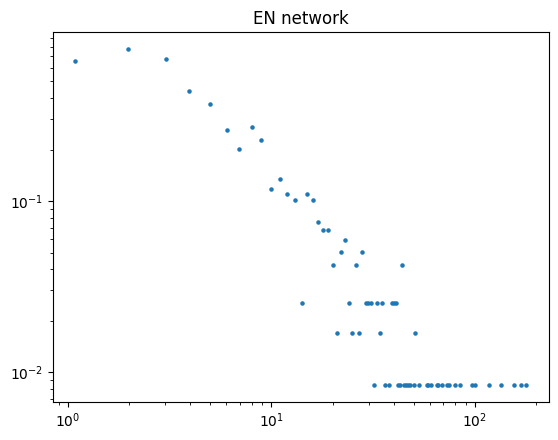

In [80]:
hist, bin_edges = np.histogram(degree_sequence_en, bins=1000, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers[hist > 0], hist[hist > 0], s=5)
plt.title('EN network')
plt.xscale('log')
plt.yscale('log')

In [81]:
fit = powerlaw.Fit(degree_sequence_ru)
print('\nalpha = ', fit.power_law.alpha)
print('x_min = ', fit.power_law.xmin)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 45/45 [00:00<00:00, 2711.83it/s]


alpha =  2.1344289956010236
x_min =  6.0



/Users/mac/Desktop/vscode/gromov/venv/lib/python3.11/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [82]:
fit = powerlaw.Fit(degree_sequence_en)
print('\nalpha = ', fit.power_law.alpha)
print('x_min = ', fit.power_law.xmin)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 65/65 [00:00<00:00, 3388.73it/s]


alpha =  2.5806882557591857
x_min =  15.0



/Users/mac/Desktop/vscode/gromov/venv/lib/python3.11/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [83]:
def attach(node, G, m):
    # your code here
    degrees = np.array([G.degree[i] for i in G.nodes])
    probs = degrees / degrees.sum()

    targets = np.random.choice(G.nodes, p=probs, size=m, replace=False)

    for t in targets:
      G.add_edge(node, t)

In [84]:
def barabasi_albert_graph(n, m):
    G = nx.star_graph(m)
    for i in range(1, n - m):
        attach(m + i, G, m)
    return G

In [85]:
def estimate_power_law(n, m_min, m_max):
    # your code here
    alpha_list = []
    x_min_list = []
    for m in range(m_min, m_max+1):
      G = barabasi_albert_graph(n , m)
      a, x = MLE_extimation(np.array([G.degree[n] for n in G.nodes]))
      x_min_list.append(x)
      alpha_list.append(a)
    return np.array(alpha_list), np.array(x_min_list)

## Power Law Testing on Actual Graphs

In [89]:
import powerlaw

# Test power law on Russian graph
degrees_ru = np.array([GG_ru.degree[n] for n in GG_ru.nodes])
fit_ru = powerlaw.Fit(degrees_ru, discrete=True)

print("Russian Graph Power Law Analysis:")
print(f"Alpha (exponent): {fit_ru.power_law.alpha:.4f}")
print(f"Xmin (minimum degree): {fit_ru.power_law.xmin}")
print(f"  Number of nodes with degree >= xmin: {len(degrees_ru[degrees_ru >= fit_ru.power_law.xmin])}")
print()

# Test power law on English graph
degrees_en = np.array([GG_en.degree[n] for n in GG_en.nodes])
fit_en = powerlaw.Fit(degrees_en, discrete=True)

print("English Graph Power Law Analysis:")
print(f"Alpha (exponent): {fit_en.power_law.alpha:.4f}")
print(f"Xmin (minimum degree): {fit_en.power_law.xmin}")
print(f"  Number of nodes with degree >= xmin: {len(degrees_en[degrees_en >= fit_en.power_law.xmin])}")
print()

print("Summary:")
print(f"Russian graph: α = {fit_ru.power_law.alpha:.4f} (scale-free if α ∈ [2,3])")
print(f"English graph: α = {fit_en.power_law.alpha:.4f} (scale-free if α ∈ [2,3])")

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 45/45 [00:00<00:00, 1564.57it/s]


Russian Graph Power Law Analysis:
Alpha (exponent): 2.0370
Xmin (minimum degree): 6.0
  Number of nodes with degree >= xmin: 152

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 65/65 [00:00<00:00, 2215.39it/s]

English Graph Power Law Analysis:
Alpha (exponent): 2.5003
Xmin (minimum degree): 15.0
  Number of nodes with degree >= xmin: 149

Summary:
Russian graph: α = 2.0370 (scale-free if α ∈ [2,3])
English graph: α = 2.5003 (scale-free if α ∈ [2,3])


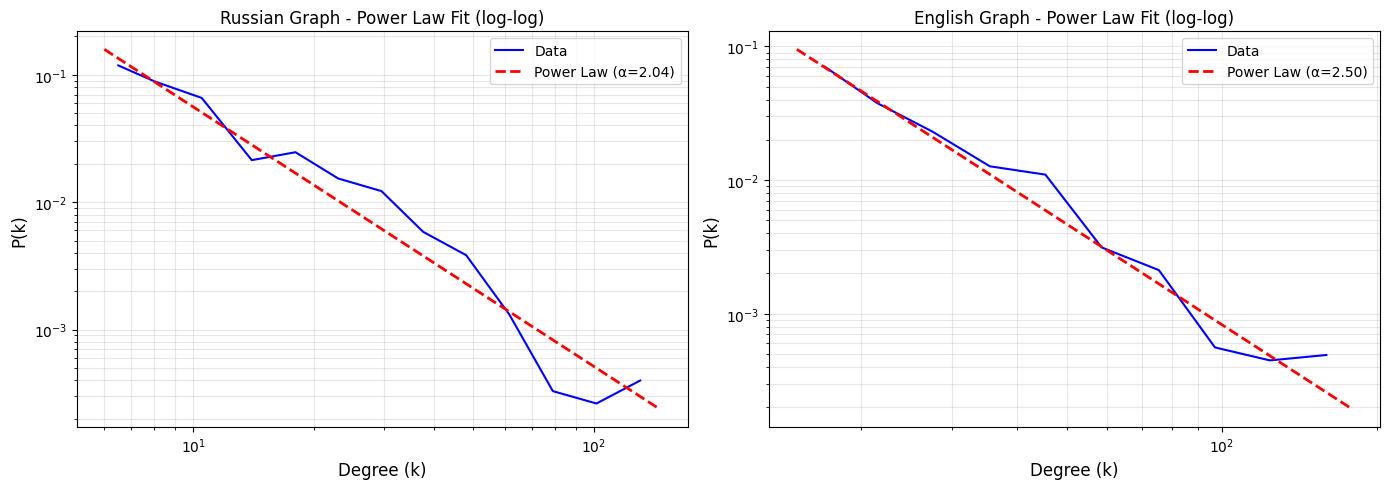

In [90]:
# Visualize power law fit (log-log plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Russian graph
ax = axes[0]
fit_ru.plot_pdf(ax=ax, color='b', linestyle='-', label='Data')
fit_ru.power_law.plot_pdf(ax=ax, color='r', linestyle='--', linewidth=2, label=f'Power Law (α={fit_ru.power_law.alpha:.2f})')
ax.set_xlabel('Degree (k)', fontsize=12)
ax.set_ylabel('P(k)', fontsize=12)
ax.set_title('Russian Graph - Power Law Fit (log-log)')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.3)

# English graph
ax = axes[1]
fit_en.plot_pdf(ax=ax, color='b', linestyle='-', label='Data')
fit_en.power_law.plot_pdf(ax=ax, color='r', linestyle='--', linewidth=2, label=f'Power Law (α={fit_en.power_law.alpha:.2f})')
ax.set_xlabel('Degree (k)', fontsize=12)
ax.set_ylabel('P(k)', fontsize=12)
ax.set_title('English Graph - Power Law Fit (log-log)')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
# Statistical analysis of power law fit
print("=" * 60)
print("POWER LAW ANALYSIS - FINAL RESULTS")
print("=" * 60)

# Russian graph
print("\nRussian Graph:")
print(f"  Alpha (exponent): {fit_ru.power_law.alpha:.4f}")
print(f"  Xmin (threshold): {fit_ru.power_law.xmin}")
print(f"  Nodes above threshold: {len(degrees_ru[degrees_ru >= fit_ru.power_law.xmin])}/{len(degrees_ru)}")

# English graph
print("\nEnglish Graph:")
print(f"  Alpha (exponent): {fit_en.power_law.alpha:.4f}")
print(f"  Xmin (threshold): {fit_en.power_law.xmin}")
print(f"  Nodes above threshold: {len(degrees_en[degrees_en >= fit_en.power_law.xmin])}/{len(degrees_en)}")

print("\n" + "=" * 60)
print("Interpretation Guide:")
print("  - α = 2-3: Scale-free network (power law)")
print("  - α < 2: Very heavy-tailed (rare)")
print("  - α > 3: Rapid decay (not scale-free)")
print("  - xmin: Degree threshold for power law fit")
print("=" * 60)

POWER LAW ANALYSIS - FINAL RESULTS

Russian Graph:
  Alpha (exponent): 2.0370
  Xmin (threshold): 6.0
  Nodes above threshold: 152/336

English Graph:
  Alpha (exponent): 2.5003
  Xmin (threshold): 15.0
  Nodes above threshold: 149/667

Interpretation Guide:
  - α = 2-3: Scale-free network (power law)
  - α < 2: Very heavy-tailed (rare)
  - α > 3: Rapid decay (not scale-free)
  - xmin: Degree threshold for power law fit


In [94]:
for name, fit_obj in [('Russian', fit_ru), ('English', fit_en)]:
    print(f"--- {name} graph distribution_compare ---")
    for alt in ['exponential', 'lognormal', 'truncated_power_law']:
        try:
            R, p = fit_obj.distribution_compare('power_law', alt)
            print(f"  vs {alt:20}: R={R:.4f}, p={p:.4f}")
        except Exception as e:
            print(f"  vs {alt:20}: failed ({e})")

--- Russian graph distribution_compare ---
  vs exponential         : R=1.5616, p=0.8542
  vs lognormal           : R=-8.0049, p=0.0134
  vs truncated_power_law : R=-8.6588, p=0.0000
--- English graph distribution_compare ---
  vs exponential         : R=6.6438, p=0.3194
  vs lognormal           : R=-2.7525, p=0.1515
  vs truncated_power_law : R=-3.0299, p=0.0138
